# NEO Classification — VDP-only ROC Curve Analysis

**Goal:** Use the May 9 velocity-density probability (VDP) maps to classify S3M benchmark objects as NEOs.

**Classification rule:** call an object a NEO if $P_\text{NEO} > x$, where $x \in [0,1]$ is a tunable threshold.

**Key quantities:**

| Symbol | Meaning |
|---|---|
| $N^\text{NEO}_\text{cand}(x)$ | True NEOs passing the cut — **true positives** |
| $N^\text{MBA}_\text{cand}(x)$ | MBAs passing the cut — **false positives** |
| $N^\text{NEO}_\text{true}$ | Total real NEOs in the visible sample |

$$\text{Completeness}(x) = \frac{N^\text{NEO}_\text{cand}(x)}{N^\text{NEO}_\text{true}}$$

$$\text{Contamination}(x) = 1 - \text{Purity}(x) = \frac{N^\text{non-NEO}_\text{cand}(x)}{N^\text{NEO}_\text{cand}(x) + N^\text{non-NEO}_\text{cand}(x)}$$

**ROC curve:** sweep $x$ from 0 → 1 and plot completeness (x-axis) vs contamination (y-axis), both in %. This notebook measures the VDP classifier alone; the digest2 comparison is handled separately in `digest2_comparison.ipynb`.

In [1]:
%reload_ext autoreload
%autoreload 2
%aimport -jax
%aimport -jaxlib
%aimport -adam_core

## 1. What is in `s3m_digest2_comparison_vdp_input_2026-05-09T22_neocp.parquet`?

This file was produced by scoring all four S3M populations (NEO, MBA, TNO, Trojan) against the May 9 VDP probability maps.  
Only objects that fall inside the 2026 May 9 NEOCP sky patch (ecliptic lon=229°, lat=0°, radius=30°), within the velocity grid, and within the map apparent-magnitude range are retained.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUN_LABEL = "2026-05-09T22_neocp"
PARQUET = f"s3m_digest2_comparison_vdp_input_{RUN_LABEL}.parquet"
FIG_PDF = f"roc_curve_vdp_only_{RUN_LABEL}.pdf"
FIG_PNG = f"roc_curve_vdp_only_{RUN_LABEL}.png"

df = pd.read_parquet(PARQUET)
score_col = "P_NEO_vdp" if "P_NEO_vdp" in df.columns else "P_NEO"

print(f"Input file: {PARQUET}")
print(f"Score column: {score_col}")
print(f"Total rows: {len(df):,}")
print(f"\nTrue population counts:")
print(df["true_population"].value_counts().to_string())
print(f"\nFirst 5 rows:")
df.head()

Input file: s3m_digest2_comparison_vdp_input_2026-05-09T22_neocp.parquet
Score column: P_NEO_vdp
Total rows: 21,027

True population counts:
true_population
MBA        10479
TNO         7492
Trojans     1937
NEO         1119

First 5 rows:


,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,...,M_obs_deg,L_obs_deg,mag_app,mag_bin_label,P_MBA,P_NEO,P_TNO,P_Trojans,true_population,P_NEO_vdp
0,S000000da,COM,1.060568,0.515926,6.920732,98.376138,339.253430,54779.042181,12.729,54466.0,...,142.335605,219.965174,17.528800,16_18,0.999723,0.000268,0.000000e+00,0.000008,NEO,0.000268
1,S000000oa,COM,0.895658,0.688721,49.344726,67.929340,358.922348,55274.711375,13.449,54466.0,...,110.461833,177.313522,19.679353,18_20,0.999268,0.000729,0.000000e+00,0.000003,NEO,0.000729
2,S000000za,COM,0.378069,0.842327,9.620640,58.763867,333.868217,55118.121455,13.901,54466.0,...,166.453225,199.085309,20.253075,mag20,0.999841,0.000157,2.053713e-07,0.000001,NEO,0.000157
3,S000000Ka,COM,0.583406,0.770496,34.196372,221.058826,190.309291,54484.303110,14.232,54466.0,...,185.824177,237.192294,20.443166,mag20,0.999688,0.000310,5.053973e-08,0.000002,NEO,0.000310
4,S000001aa,COM,0.776497,0.568033,18.616025,193.265921,154.160956,54262.277140,14.778,54466.0,...,304.887019,292.313895,16.284954,16_18,0.000000,0.649452,0.000000e+00,0.000000,NEO,0.649452


### Column descriptions

| Column | Description |
|---|---|
| `true_population` | Ground truth: which S3M population this object came from (NEO / MBA / TNO / Trojans) |
| `vlam` | Ecliptic longitude rate $\dot{\lambda}$ (deg/day) — x-axis of the velocity map |
| `vbeta` | Ecliptic latitude rate $\dot{\beta}$ (deg/day) — y-axis of the velocity map |
| `mag_app` | Apparent magnitude at the observation epoch |
| `mag_bin_label` | Which magnitude bin was used to look up the probability map |
| `H` | Absolute magnitude |
| `P_NEO` / `P_NEO_vdp` | **Probability this object is a NEO** — the classifier score |
| `P_MBA` | Probability this object is an MBA |
| `P_TNO` | Probability this object is a TNO |
| `P_Trojans` | Probability this object is a Trojan |

Probabilities are derived by normalising the per-population kNN density maps. Cells outside the nearest-object mask have zero probability.

## 2. ROC Curve Calculation

We sweep the threshold $x$ from 0 to 1 using the same 201-point grid as `run_digest2_comparison.py`.  
At each $x$ we count how many true NEOs and how many impostors pass the cut $P_\text{NEO} > x$.

In [3]:
# Ground truth masks
is_neo = df["true_population"] == "NEO"
p_neo  = df[score_col].to_numpy()

N_true_NEO = is_neo.sum()         # total real NEOs visible in the sky patch
print(f"N_true_NEO = {N_true_NEO:,}  (all real NEOs in the sample)")
print(f"N_non_NEO  = {(~is_neo).sum():,}  (MBA + TNO + Trojans combined)")

# Sweep thresholds. This matches the grid used by run_digest2_comparison.py.
thresholds = np.linspace(0, 1, 201)

N_cand_NEO = np.array([(p_neo[is_neo]   > x).sum() for x in thresholds])   # true positives
N_cand_nonNEO = np.array([(p_neo[~is_neo] > x).sum() for x in thresholds]) # false positives
N_cand_total = N_cand_NEO + N_cand_nonNEO

# Key metrics (in %)
completeness  = 100.0 * N_cand_NEO / N_true_NEO
# contamination = fraction of candidates that are NOT true NEOs
contamination = 100.0 * N_cand_nonNEO / np.maximum(N_cand_total, 1)

# Check the low-threshold end. Objects with exactly zero VDP probability still fail P_NEO > 0.
i0 = 0   # threshold = 0.0
print(f"\nAt x=0 (select P_NEO > 0):")
print(f"  Completeness  = {completeness[i0]:.1f}%")
print(f"  Contamination = {contamination[i0]:.1f}%")

# Check the high-threshold end.
i1 = -1  # threshold = 1.0
print(f"\nAt x=1 (accept nothing):")
print(f"  Completeness  = {completeness[i1]:.1f}%  (should be ~0%)")
print(f"  N candidates  = {N_cand_total[i1]}")

N_true_NEO = 1,119  (all real NEOs in the sample)
N_non_NEO  = 19,908  (MBA + TNO + Trojans combined)

At x=0 (select P_NEO > 0):
  Completeness  = 100.0%
  Contamination = 94.7%

At x=1 (accept nothing):
  Completeness  = 0.0%  (should be ~0%)
  N candidates  = 0


## 3. ROC Curve Plot

**x-axis:** Completeness — how many real NEOs we recover  
**y-axis:** Contamination — fraction of our candidate list that are impostors  

**Ideal detector:** bottom-right corner (100% completeness, 0% contamination)  
**Reference:** the VDP-vs-digest2 comparison notebook uses the same VDP score column on this benchmark sample, then adds digest2 scores for the same objects.

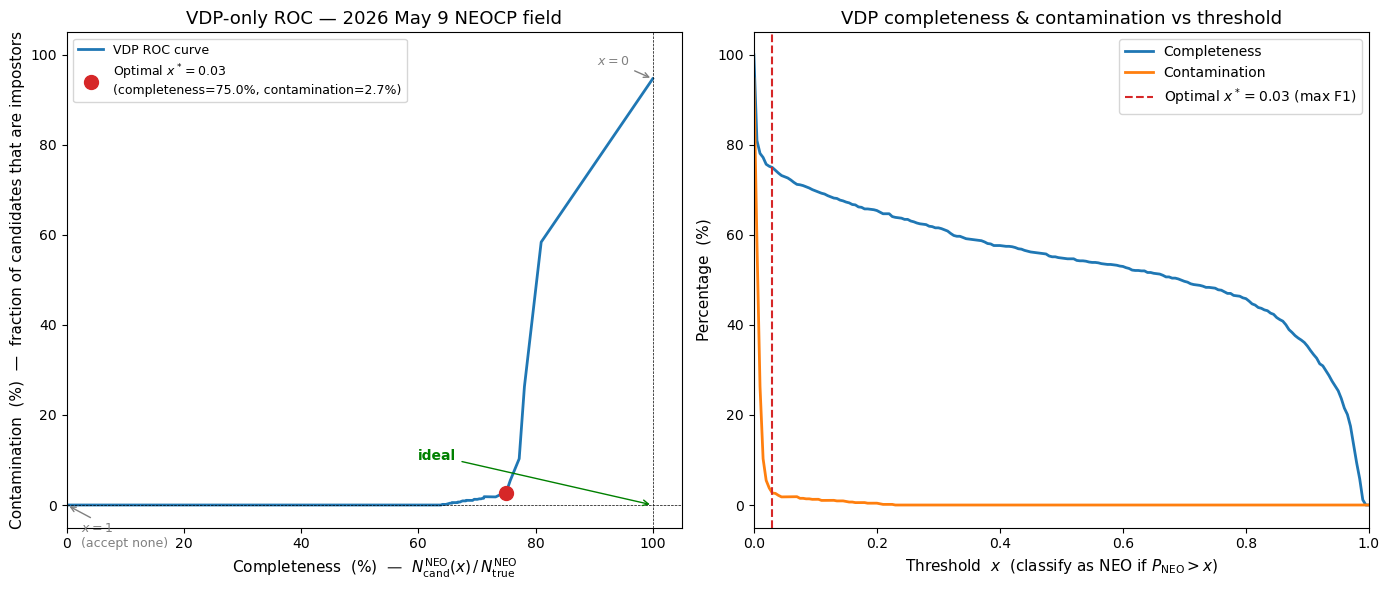

Optimal threshold  x* = 0.030  (maximises F1-score)
  N_cand_NEO    = 839   (true NEOs recovered)
  N_cand_nonNEO = 23  (impostors passing cut)
  Completeness  = 75.0%
  Contamination = 2.7%
  Purity        = 97.3%
Saved: roc_curve_vdp_only_2026-05-09T22_neocp.pdf
Saved: roc_curve_vdp_only_2026-05-09T22_neocp.png


In [4]:
# Optimal threshold: maximise F1 
purity = 100.0 - contamination                          # in %
# F1 in % units
f1 = 2 * (purity * completeness) / np.maximum(purity + completeness, 1e-9)
i_star = np.argmax(f1)
x_star = thresholds[i_star]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: ROC curve (completeness vs contamination) 
ax = axes[0]
ax.plot(completeness, contamination, lw=2, color="tab:blue", label="VDP ROC curve")

# Mark the optimal threshold
ax.scatter(
    [completeness[i_star]], [contamination[i_star]],
    s=100, zorder=5, color="tab:red",
    label=f"Optimal $x^*={x_star:.2f}$\n"
          f"(completeness={completeness[i_star]:.1f}%, "
          f"contamination={contamination[i_star]:.1f}%)"
)

# Annotate the x=0 and x=1 endpoints
ax.annotate("$x=0$",
            xy=(completeness[0], contamination[0]),
            xytext=(-40, 10), textcoords="offset points",
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.annotate("$x=1$\n(accept none)",
            xy=(completeness[-1], contamination[-1]),
            xytext=(10, -30), textcoords="offset points",
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("Completeness  (%)  —  $N^\\text{NEO}_\\text{cand}(x)\\, /\\, N^\\text{NEO}_\\text{true}$", fontsize=11)
ax.set_ylabel("Contamination  (%)  —  fraction of candidates that are impostors", fontsize=11)
ax.set_title("VDP-only ROC — 2026 May 9 NEOCP field", fontsize=13)
ax.set_xlim(0, 105)
ax.set_ylim(-5, 105)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.axvline(100, color="k", lw=0.5, ls="--")
ax.annotate("ideal", xy=(100, 0), xytext=(60, 10), fontsize=10,
            color="green", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="green"))
ax.legend(fontsize=9)

# Panel 2: Completeness & Contamination vs threshold x 
ax2 = axes[1]
ax2.plot(thresholds, completeness,  lw=2, label="Completeness",  color="tab:blue")
ax2.plot(thresholds, contamination, lw=2, label="Contamination", color="tab:orange")
ax2.axvline(x_star, color="tab:red", lw=1.5, ls="--",
            label=f"Optimal $x^*={x_star:.2f}$ (max F1)")
ax2.set_xlabel("Threshold  $x$  (classify as NEO if $P_\\text{NEO} > x$)", fontsize=11)
ax2.set_ylabel("Percentage  (%)", fontsize=11)
ax2.set_title("VDP completeness & contamination vs threshold", fontsize=13)
ax2.set_xlim(0, 1)
ax2.set_ylim(-5, 105)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_PDF, dpi=150, bbox_inches="tight")
plt.savefig(FIG_PNG, dpi=180, bbox_inches="tight")
plt.show()

# Summary 
print(f"Optimal threshold  x* = {x_star:.3f}  (maximises F1-score)")
print(f"  N_cand_NEO    = {N_cand_NEO[i_star]:,}   (true NEOs recovered)")
print(f"  N_cand_nonNEO = {N_cand_nonNEO[i_star]:,}  (impostors passing cut)")
print(f"  Completeness  = {completeness[i_star]:.1f}%")
print(f"  Contamination = {contamination[i_star]:.1f}%")
print(f"  Purity        = {100-contamination[i_star]:.1f}%")
print(f"Saved: {FIG_PDF}")
print(f"Saved: {FIG_PNG}")